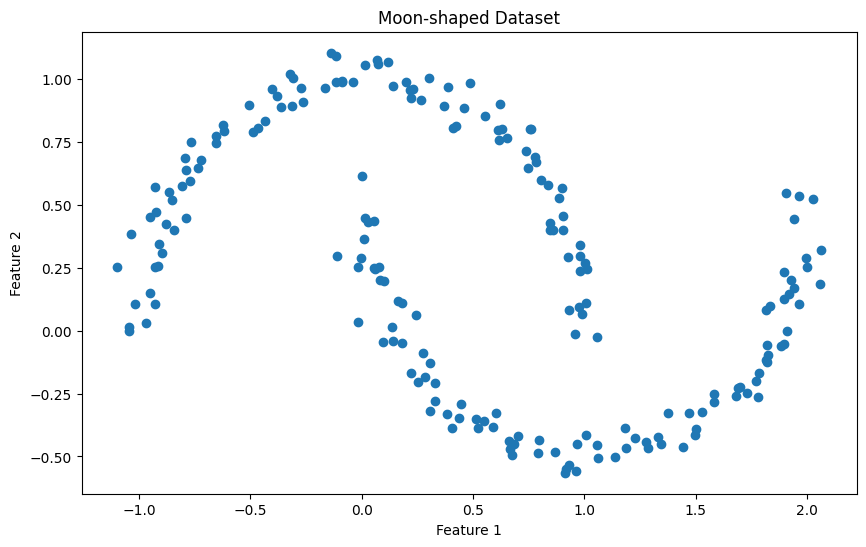

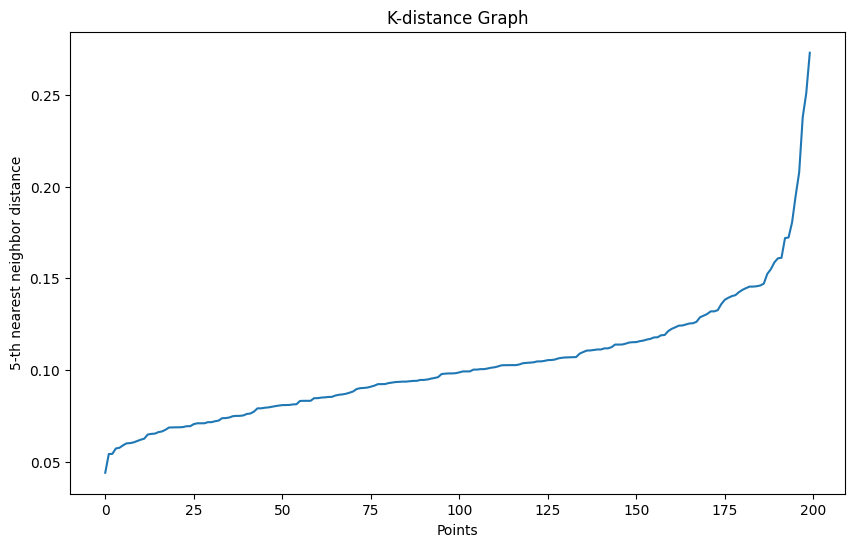

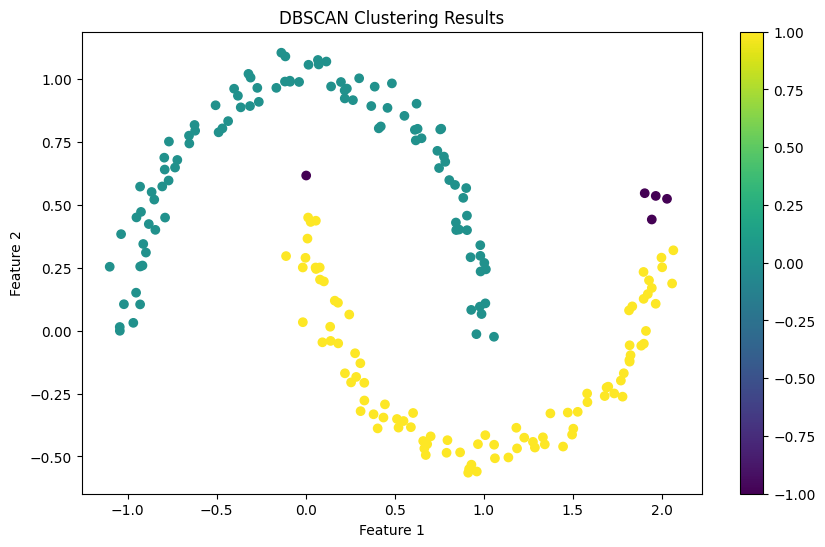

Number of clusters: 2
Number of noise points: 5


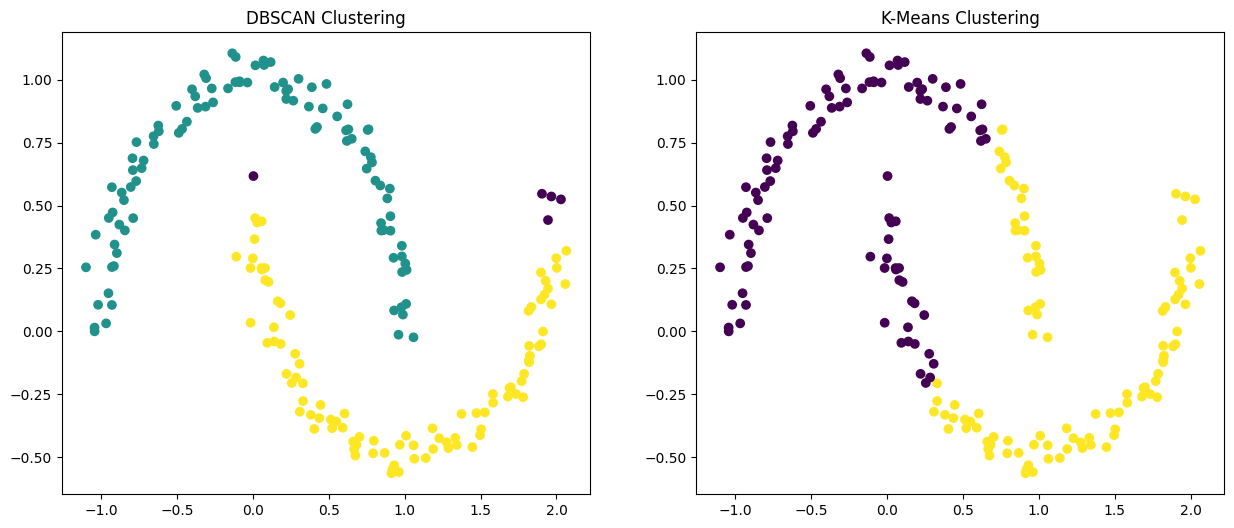

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

X, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

# Visualize the dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k=5)

# Perform DBSCAN clustering
epsilon = 0.15  # Chosen based on k-distance graph
min_samples = 5  # 2 * num_features (2D data)
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
clusters = dbscan.fit_predict(X)

# Visualize the results
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Print number of clusters and noise points
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

from sklearn.cluster import KMeans

# DBSCAN clustering
dbscan = DBSCAN(eps=0.15, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Visualize the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis')
ax1.set_title('DBSCAN Clustering')

ax2.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis')
ax2.set_title('K-Means Clustering')

plt.show()


Cluster Labels: [ 0  0  0  1  1  1  2  2  2 -1  1]


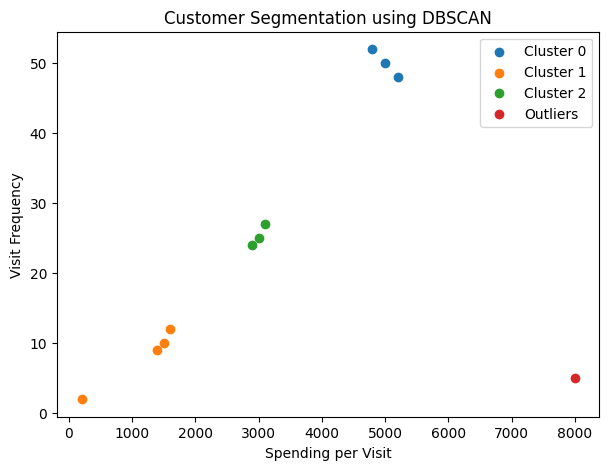

In [ ]:
# Customer Segmentation using DBSCAN

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Customer dataset: [Spending per visit, Visit frequency]
data = np.array([
    [5000, 50], [5200, 48], [4800, 52],   # Loyal high spenders
    [1500, 10], [1600, 12], [1400, 9],    # Occasional visitors
    [3000, 25], [3100, 27], [2900, 24],   # Moderate spenders
    [8000, 5],                            # Outlier: rare but huge spender
    [200, 2]                              # Outlier: very low engagement
])

# Step 1: Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Step 2: Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=2)
labels = dbscan.fit_predict(scaled_data)

# Step 3: Print cluster labels
print("Cluster Labels:", labels)

# Step 4: Plot clusters
plt.figure(figsize=(7,5))

unique_labels = set(labels)
for label in unique_labels:
    if label == -1:
        color = 'red'   # Outliers
        label_name = "Outliers"
    else:
        color = None
        label_name = f"Cluster {label}"

    plt.scatter(data[labels == label, 0],
                data[labels == label, 1],
                label=label_name)

plt.xlabel("Spending per Visit")
plt.ylabel("Visit Frequency")
plt.title("Customer Segmentation using DBSCAN")
plt.legend()
plt.show()